<a href="https://colab.research.google.com/github/kjahan/graph_embeddings/blob/main/notebooks/node2vec_karate_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INforcome 2006 dataset

## Clone node2vec repo

Let's try this librray that seems to implement te Python 3 versiion of node2vec: https://github.com/eliorc/node2vec

Note that the original source code seems to not working for Python 3. Got the following errors:

!python node2vec/src/main.py --input graph/karate.edgelist --output node2vec/emb/karate.emd

Traceback (most recent call last): File "node2vec/src/main.py", line 15, in <module> import node2vec File "/content/node2vec/src/node2vec.py", line 46 print 'Walk iteration:' ^ SyntaxError: Missing parentheses in call to 'print'. Did you mean print('Walk iteration:')?

https://github.com/aditya-grover/node2vec

https://snap.stanford.edu/node2vec/

In [1]:
!git clone https://github.com/eliorc/node2vec.git

Cloning into 'node2vec'...
remote: Enumerating objects: 292, done.
remote: Counting objects: 100% (146/146), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 292 (delta 108), reused 96 (delta 88), pack-reused 146
Receiving objects: 100% (292/292), 68.30 KiB | 1.31 MiB/s, done.
Resolving deltas: 100% (168/168), done.


In [2]:
!pip install node2vec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 8.2 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.2.1
    Uninstalling networkx-3.2.1:
      Successfully uninstalled networkx-3.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lida 0.0.10 requires fastapi, which is not installed.
lida 0.0.10 requires kaleido, which is not installed.
lida 0.0.10 requires python-multipart, which is not installed.
lida 0.0.10 requires uvicorn, which is not installed.


In [3]:
import networkx as nx
from node2vec import Node2Vec

## Download karate data

In [11]:
!mkdir data

mkdir: cannot create directory ‘data’: File exists


In [13]:
!wget  -P data/ https://raw.githubusercontent.com/bagrow/datatools/master/tutorial/karate.edgelist

--2023-12-02 21:39:40--  https://raw.githubusercontent.com/bagrow/datatools/master/tutorial/karate.edgelist
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 405 [text/plain]
Saving to: ‘data/karate.edgelist’

karate.edgelist     100%[===================>]     405  --.-KB/s    in 0s      

2023-12-02 21:39:40 (30.9 MB/s) - ‘data/karate.edgelist’ saved [405/405]



In [16]:
!head -n 10 data/karate.edgelist

0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10


## Load karate graph

In [17]:
G = nx.read_edgelist('data/karate.edgelist', nodetype=int, create_using=nx.DiGraph())
G = G.to_undirected()

In [18]:
G.number_of_nodes()

34

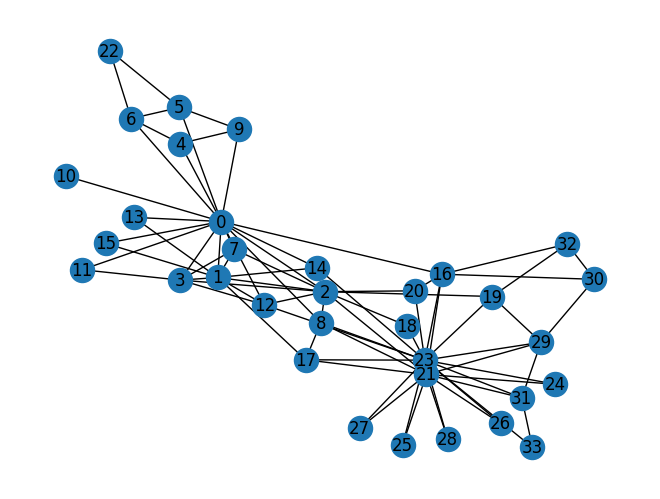

In [19]:
nx.draw(G, with_labels = True)

## Run Node2Vec

In [20]:
# Precompute probabilities and generate walks - **ON WINDOWS ONLY WORKS WITH workers=1**
node2vec = Node2Vec(G, dimensions=64, walk_length=5, num_walks=20, workers=4)  # Use temp_folder for big graphs

# Embed nodes
# Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

Computing transition probabilities:   0%|          | 0/34 [00:00<?, ?it/s]

## similar nodes to 0

In [21]:
# Look for most similar nodes
model.wv.most_similar('0')  # Output node names are always strings

[('21', 0.6984439492225647),
 ('4', 0.6158362030982971),
 ('16', 0.5790340304374695),
 ('6', 0.5591412782669067),
 ('17', 0.5369686484336853),
 ('2', 0.5278401970863342),
 ('23', 0.5167043805122375),
 ('7', 0.5081422328948975),
 ('31', 0.49552279710769653),
 ('19', 0.4886517822742462)]

In [22]:
model.wv.most_similar('19')  # Output node names are always strings

[('21', 0.5977829694747925),
 ('16', 0.5683531165122986),
 ('2', 0.5180325508117676),
 ('0', 0.48865172266960144),
 ('6', 0.4733614921569824),
 ('4', 0.4642930328845978),
 ('29', 0.4631025791168213),
 ('14', 0.4489905536174774),
 ('23', 0.44597047567367554),
 ('3', 0.44264060258865356)]